In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(
    host="localhost",
    username="root",
    password="password",
    database="ecommerce")

cur = db.cursor()




# 1. List all unique cities where customers are located.

In [19]:
query="""select distinct(customer_city) from customers"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# 2. Count the number of orders placed in 2017.

In [3]:
query="""select count(order_id) from orders where year(order_purchase_timestamp)=2017"""
cur.execute(query)
data = cur.fetchall()
"Total Orders in 2017 are",data[0][0]

('Total Orders in 2017 are', 45101)

# 3. Find the total sales per category.(Max And Min Sales)

In [4]:
query="""select products.product_category as Categories,round(sum(payments.payment_value),2) as Sales from products
join order_items on products.product_id=order_items.product_id
join payments on payments.order_id=order_items.order_id
group by Categories
order by sales desc
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["Category","Sales"])
df

,Category,Sales
0,bed table bath,1712553.67
1,HEALTH BEAUTY,1657373.12
2,computer accessories,1585330.45
3,Furniture Decoration,1430176.39
4,Watches present,1429216.68
...,...,...
69,PC Gamer,2174.43
70,House Comfort 2,1710.54
71,cds music dvds,1199.43
72,Fashion Children's Clothing,785.67


# 4. Calculate the percentage of orders that were paid in installments.

In [5]:
query="""select sum(case when payment_installments >= 1 then 1
else 0 end)/count(*)*100 from Payments"""
cur.execute(query)
data = cur.fetchall()
data

[(Decimal('99.9981'),)]

# 5. Count the number of customers from each state.

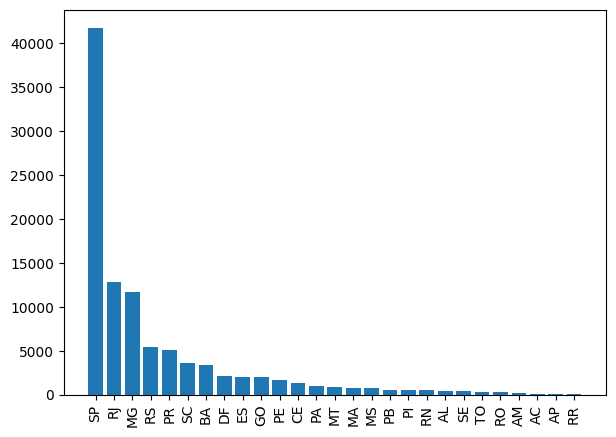

In [6]:
query="""select customer_state,count(customer_state) as cnt from customers
group by customer_state 
order by cnt desc  """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["State","Customers"])
plt.figure(figsize=(7,5))
plt.bar(df["State"],df["Customers"])
plt.xticks(rotation=90)
plt.show()

# Intermediate Queries
# 1. Calculate the number of orders per month in 2018.

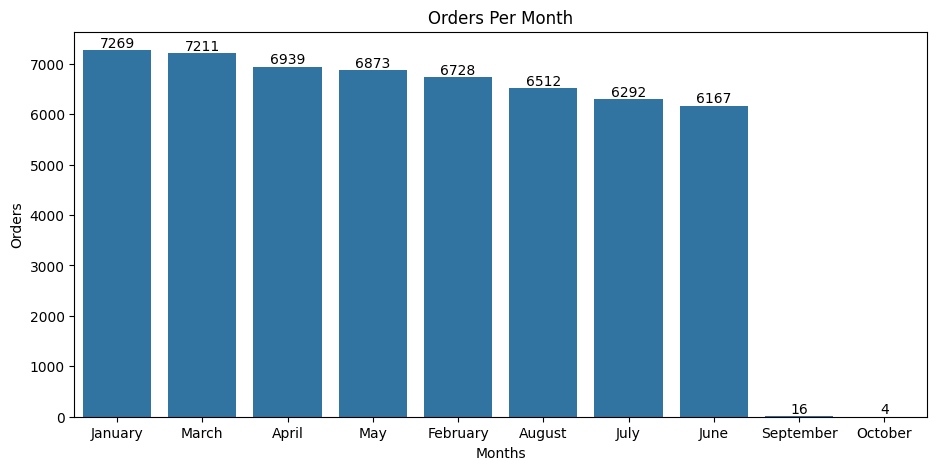

In [7]:
query="""select monthname(order_purchase_timestamp) as months,count(order_id) from orders
where year(order_purchase_timestamp)=2018
group by months
order by count(order_id) desc"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["Months","Orders"])
plt.figure(figsize=(11,5))
ax = sns.barplot(df,x="Months",y="Orders")
ax.bar_label(ax.containers[0])
plt.title("Orders Per Month")
plt.show()

# 2. Find the average number of products per order, grouped by customer city.

In [8]:
query="""with count_per_order as
(select orders.order_id,orders.customer_id,count(order_items.order_id) as oc
from orders join order_items 
on orders.order_id=order_items.order_id
group by orders.order_id,orders.customer_id)

select customers.customer_city,round(avg(count_per_order.oc),2) as Avg_Per_Orders from Customers
join count_per_order on customers.customer_id=count_per_order.customer_id
group by customers.customer_city
order by Avg_Per_Orders desc limit 5"""
cur.execute(query)
data = cur.fetchall()
data

[('padre carvalho', Decimal('7.00')),
 ('celso ramos', Decimal('6.50')),
 ('datas', Decimal('6.00')),
 ('candido godoi', Decimal('6.00')),
 ('matias olimpio', Decimal('5.00'))]

# 3. Calculate the percentage of total revenue contributed by each product category.

In [9]:
query="""select products.product_category as Categories,round((sum(payments.payment_value)/(Select sum(payment_value) from payments))*100,2)
as Percentage_Sales from products
join order_items on products.product_id=order_items.product_id
join payments on payments.order_id=order_items.order_id
group by Categories
order by Percentage_Sales desc limit 5
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["Category","Percentage Of Sales"])
df

,Category,Percentage Of Sales
0,bed table bath,10.70
1,HEALTH BEAUTY,10.35
2,computer accessories,9.90
3,Furniture Decoration,8.93
4,Watches present,8.93


# 4. Identify the correlation between product price and the number of times a product has been purchased.

In [10]:
import numpy as np
query="""select products.product_category,count(order_items.product_id),round(avg(order_items.price),2)
from products join order_items 
on products.product_id=order_items.product_id
group by  products.product_category"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["Category","Order_Count","Avg_Price/Order"])
arr1=df["Order_Count"]
arr2=df["Avg_Price/Order"]
np.corrcoef([arr1,arr2])
# Very much close to 0 its neutral so no relation among them.

array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

# 5. Calculate the total revenue generated by each seller, and rank them by revenue.

In [11]:
query="""select *,dense_rank() over(order by revenue desc) as rn from 
(select order_items.seller_id,sum(payments.payment_value) as Revenue
from order_items join payments
on order_items.order_id=payments.order_id
group by order_items.seller_id) as seller_revenue limit 5"""
cur.execute(query)
data = cur.fetchall()
data

[('7c67e1448b00f6e969d365cea6b010ab', 507166.9073021412, 1),
 ('1025f0e2d44d7041d6cf58b6550e0bfa', 308222.0398402214, 2),
 ('4a3ca9315b744ce9f8e9374361493884', 301245.26976528764, 3),
 ('1f50f920176fa81dab994f9023523100', 290253.42012761533, 4),
 ('53243585a1d6dc2643021fd1853d8905', 284903.0804977417, 5)]

# Advanced Queries
# 1. Calculate the moving average of order values for each customer over their order history.

In [12]:
query="""
select customer_id,order_purchase_timestamp,payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,payments.payment_value as payment
from payments join orders on payments.order_id=orders.order_id)as a;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# 2. Calculate the cumulative sales per month for each year.

In [13]:
query="""select year,months,payments , sum(payments) over (order by year,months) as Cumulative_Sales from
(select year(orders.order_purchase_timestamp) as Year,
month(orders.order_purchase_timestamp) as Months,
round(sum(payments.payment_value),2) as Payments from orders join payments
on orders.order_id=payments.order_id
group by year,months
order by year,months) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 3. Calculate the year-over-year growth rate of total sales.

In [14]:
query="""with a as (select year(orders.order_purchase_timestamp) as Year,
round(sum(payments.payment_value),2) as Payments from orders join payments
on orders.order_id=payments.order_id
group by year
order by year)
select year , ((payments-lag(payments,1) over(order by year))/lag(payments,1)
over(order by year)) *100 as Percentage_Growth from a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["Year","Percentage Growth"])
df

,Year,Percentage Growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [15]:
query="""with a as (select customers.customer_id,min(orders.order_purchase_timestamp) First_Order
from customers join orders on
customers.customer_id=orders.customer_id
group by customers.customer_id),
b as
(select a.customer_id,count(distinct orders.order_purchase_timestamp) from a
join orders on orders.customer_id=a.customer_id
and orders.order_purchase_timestamp> First_Order
and  orders.order_purchase_timestamp < date_add(first_Order,interval 8 month)
group by  a.customer_id)
select 100 * (count(distinct a.customer_id)/count(distinct b.customer_id))
from a left join b on  a.customer_id= b.customer_id"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df
# No Repeated Customers.

,0
0,None


# 5. Identify the top 5 customers who spent the most money in each year.

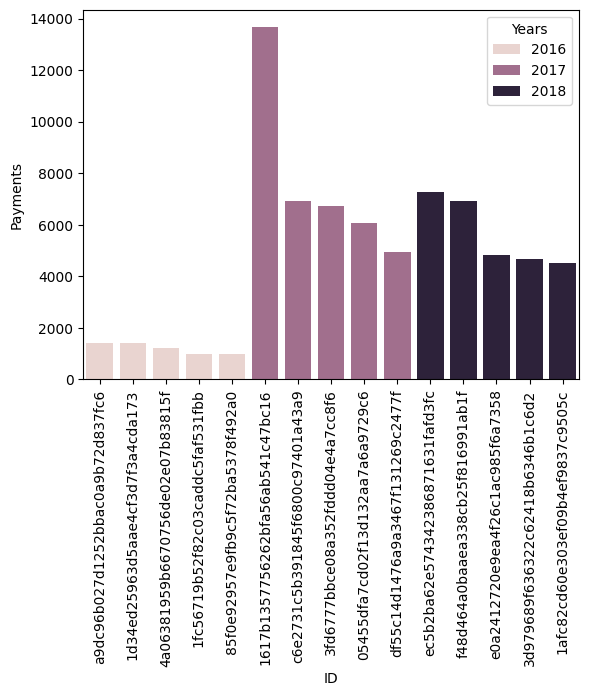

In [17]:
query="""select years,customer_id,payment,D_Rank from
(select year(orders.order_purchase_timestamp) as years,orders.order_id,orders.customer_id,round(sum(payments.payment_value),2) as payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) as D_Rank
from orders join payments on
orders.order_id=payments.order_id
group by  year(orders.order_purchase_timestamp),orders.order_id,orders.customer_id)as a 
where d_Rank <=5"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=["Years","ID","Payments","Rank"])
sns.barplot(df,x="ID",y="Payments",hue="Years")
plt.xticks(rotation=90)
plt.show()